<a href="https://colab.research.google.com/github/JulieHohenberg/DeepLearningFinal2025/blob/main/notebooks/classifier_inference_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inference Script — CLIP + VAE Feature Fusion Classifier  
**File:** `inference_turn_in_copy_img2img_clip_mlp_v1.py`

---

## Purpose
This script performs **inference** using the saved CNN and MLP classifiers on both the real and AI-generated Beatles images, as well as Tim’s childhood artwork and its AI-generated counterparts.

The pipeline uses fused features from:

1. **CLIP image embeddings** (512-D semantic features)  
2. **Stable Diffusion VAE latents** (pooled to 256-D structural features)  

These vectors are concatenated into a **768-D fused embedding**, passed into a trained classifier such as:

- **FusionMLP** → `768 → 512 → 128 → 2`
- **Simple1DCNN** → 1D convolutional feature extractor + classifier head

---

## Methods Summary
- Loads **CLIP (openai/clip-vit-base-patch32)** for global semantic features.  
- Loads **Stable Diffusion v1.5 VAE** to extract structural latent-space representations.  
- Applies resizing + normalization for VAE input (maps to [-1, 1]).  
- Concatenates CLIP + VAE features → **fused feature**.  
- Runs inference using the chosen model (`MLP` or `CNN`).  
- Provides:
  - Single-image inference
  - Folder-level evaluation with `classification_report`
  - Optional **Grad-CAM heatmaps** for VAE encoder interpretability  

---

## Dependencies
- `torch`  
- `torchvision`  
- `transformers` (CLIPProcessor, CLIPModel)  
- `diffusers` (AutoencoderKL)  
- `Pillow`  
- `numpy`  
- `scikit-learn` (for eval metrics)  
- `grad-cam` (for VAE Grad-CAM)  
- `matplotlib`  

---

## Required Model Weights
Place these in your project directory or update paths in the script:

- `fusion_mlp_best.pt` — trained MLP classifier  
- `fusion_CNN_best.pt` — trained 1D CNN classifier  

---

## Outputs
- Predictions for individual images  
- Full classification report (Precision / Recall / F1)  
- Optional VAE Grad-CAM heatmaps highlighting regions influencing latent encoding  

---

## Device Behavior
The script automatically selects:

- **GPU (CUDA)** if available  
- **CPU** otherwise  

---

## Notes
- CLIP and VAE are **lazily loaded** and cached globally for efficiency.  
- VAE input normalization follows Stable Diffusion conventions.  
- The classifier expects a **768-D fused input vector**.  

---

## Load models and import necessary items

In [ ]:
import random
seed = 42

Mount Drive (if running this alone and not mounting earlier)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import needed stuff for loaded models

In [ ]:
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Define FusionMLP

In [ ]:
class FusionMLP(nn.Module):
    def __init__(self, in_dim=768, hidden=512, hidden2=128, num_classes=2, p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p),
            nn.Linear(hidden, hidden2),
            nn.ReLU(inplace=True),
            nn.Dropout(p),
            nn.Linear(hidden2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

Define Simple1DCNN

In [ ]:
class Simple1DCNN(nn.Module):
    """
    1D CNN classifier for CLIP features.
    Treats the 768-dim feature vector as a 1D sequence and applies convolutions.
    """
    def __init__(self, in_dim=768, num_classes=2, dropout=0.3):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Conv1d(1, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)  # 768 -> 384

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)  # 384 -> 192

        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)  # 192 -> 96

        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Classifier head
        self.fc1 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Input: (batch, 768)
        x = x.unsqueeze(1)  # (batch, 1, 768) - add channel dimension

        # Conv blocks
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        # Global pooling
        x = self.global_pool(x).squeeze(-1)  # (batch, 256)

        # Classifier
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)

        return x

Load best saved model

In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F
import os

# ----------------------------------------
# Choose which classifier to load:
#   "MLP"  → FusionMLP
#   "CNN"  → Simple1DCNN
# ----------------------------------------
MODEL_TYPE = "MLP"

# ----------------------------------------
# Define paths (update these if needed)
# ----------------------------------------
MLP_PATH = "/content/drive/MyDrive/Deep_Learning_Final_Project/saved_classifier_models/fusion_mlp_best.pt"
CNN_PATH = "/content/drive/MyDrive/Deep_Learning_Final_Project/saved_classifier_models/fusion_CNN_best.pt"

# ----------------------------------------
# Load selected model
# ----------------------------------------
if MODEL_TYPE == "MLP":
    model = FusionMLP(in_dim=768)
    load_path = MLP_PATH
elif MODEL_TYPE == "CNN":
    model = Simple1DCNN(in_dim=768)
    load_path = CNN_PATH
else:
    raise ValueError("MODEL_TYPE must be either 'MLP' or 'CNN'.")

# Load weights from Drive
print(f"🔄 Loading {MODEL_TYPE} model from:\n{load_path}")

model.load_state_dict(torch.load(load_path, map_location=device))
model = model.to(device)
model.eval()

print(f"{MODEL_TYPE} model loaded and ready for inference!")

🔄 Loading MLP model from:
/content/drive/MyDrive/Deep_Learning_Final_Project/saved_classifier_models/fusion_mlp_best.pt
MLP model loaded and ready for inference!


In [ ]:
mlp_path = "/content/drive/MyDrive/Deep_Learning_Final_Project/saved_classifier_models/fusion_MLP_best.pt"

print("Exists:", os.path.exists(mlp_path))
!ls -l "/content/drive/MyDrive/Deep_Learning_Final_Project/saved_classifier_models"

Exists: False
total 2491
-rw------- 1 root root  708560 Dec  3 18:25 fusion_CNN_best.pt
-rw------- 1 root root 1841845 Dec  3 18:20 fusion_mlp_best.pt


## Do inference

Helper function to VAE + CLIP extract features for one image at a time

In [ ]:
def extract_single_feature(img_path):
    import torch
    import torch.nn.functional as F
    from PIL import Image
    from torchvision import transforms
    from transformers import CLIPProcessor, CLIPModel
    from diffusers import AutoencoderKL

    global clip_proc, clip_model, vae, device

    # -------------------------------
    # 1. Load CLIP (fast)
    # -------------------------------
    if "clip_proc" not in globals():
        clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    if "clip_model" not in globals():
        clip_model = CLIPModel.from_pretrained(
            "openai/clip-vit-base-patch32"
        ).to(device)
        clip_model.eval()

    # -------------------------------
    # 2. Load ONLY the VAE (fast)
    # -------------------------------
    if "vae" not in globals():
        vae = AutoencoderKL.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            subfolder="vae",
            torch_dtype=torch.float16
        ).to(device)
        vae.eval()

    # -------------------------------
    # 3. Load Image
    # -------------------------------
    pil = Image.open(img_path).convert("RGB")

    # -------------------------------
    # 4. CLIP Features
    # -------------------------------
    clip_inputs = clip_proc(images=pil, return_tensors="pt").to(device)
    clip_vec = clip_model.get_image_features(**clip_inputs)
    clip_vec = F.normalize(clip_vec.float(), dim=-1)  # (1,512)

    # -------------------------------
    # 5. VAE Latents
    # -------------------------------
    vae_tfms = transforms.Compose([
        transforms.Resize((512,512)),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: t * 2.0 - 1.0)
    ])

    x = vae_tfms(pil).unsqueeze(0).to(device, dtype=torch.float16)

    posterior = vae.encode(x)
    lat = posterior.latent_dist.mean
    lat = 0.18215 * lat
    pooled = F.adaptive_avg_pool2d(lat, (8,8)).flatten(1).float()

    # -------------------------------
    # 6. Fuse CLIP + VAE features
    # -------------------------------
    fused = torch.cat([clip_vec.float(), pooled], dim=1)  # (1,768)
    return fused

### Beatles Inference

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Deep_Learning_Final_Project/beatles_inference"

# direct paths to the images
img_real = os.path.join(BASE_DIR, "beatles_real.png")
img_ai   = os.path.join(BASE_DIR, "beatles_AI.png")

# extract fused features using  CLIP + VAE pipeline
feat_real = extract_single_feature(img_real).to(device)
feat_ai   = extract_single_feature(img_ai).to(device)

with torch.no_grad():
    logit_real = model(feat_real)   # → tensor([1,2])
    logit_ai   = model(feat_ai)

pred_real = torch.argmax(logit_real).item()
pred_ai   = torch.argmax(logit_ai).item()

classes = ["AI_GENERATED", "NON_AI_GENERATED"]

print("Real image prediction:", classes[pred_real])
print("AI image prediction:", classes[pred_ai])

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Real image prediction: NON_AI_GENERATED
AI image prediction: AI_GENERATED


### Inference on Tim's artwork

In [ ]:
import os
import torch
from sklearn.metrics import classification_report

# =========================================
# Path setup
# =========================================
BASE_TEST_DIR = "/content/drive/MyDrive/Deep_Learning_Final_Project/LLM_TEST"
AI_DIR   = os.path.join(BASE_TEST_DIR, "AI")
REAL_DIR = os.path.join(BASE_TEST_DIR, "Real")

classes = ["AI_GENERATED", "NON_AI_GENERATED"]  # same indexing as model
model.eval()

# =========================================
# Helper: run one image through pipeline
# =========================================
def predict_image(path):
    feat = extract_single_feature(path).to(device)
    with torch.no_grad():
        logit = model(feat)
    return torch.argmax(logit).item()   # 0 = AI_GENERATED, 1 = NON_AI_GENERATED

# =========================================
# Walk folders + evaluate
# =========================================
y_true = []
y_pred = []
file_list = []

# ---- AI images (label = 0) ----
for fname in os.listdir(AI_DIR):
    if fname.lower().endswith((".png", ".jpg", ".jpeg")):
        fpath = os.path.join(AI_DIR, fname)
        pred = predict_image(fpath)
        y_pred.append(pred)
        y_true.append(0)
        file_list.append(fpath)

# ---- Real images (label = 1) ----
for fname in os.listdir(REAL_DIR):
    if fname.lower().endswith((".png", ".jpg", ".jpeg")):
        fpath = os.path.join(REAL_DIR, fname)
        pred = predict_image(fpath)
        y_pred.append(pred)
        y_true.append(1)
        file_list.append(fpath)

# =========================================
# Print evaluation
# =========================================
print("Evaluated", len(y_true), "images\n")
print(classification_report(y_true, y_pred, target_names=classes))

Evaluated 24 images

                  precision    recall  f1-score   support

    AI_GENERATED       1.00      0.29      0.44        14
NON_AI_GENERATED       0.50      1.00      0.67        10

        accuracy                           0.58        24
       macro avg       0.75      0.64      0.56        24
    weighted avg       0.79      0.58      0.54        24



### VAE Grad-CAM on the Beatles images

In [ ]:
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


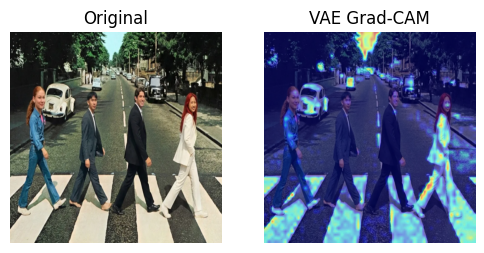

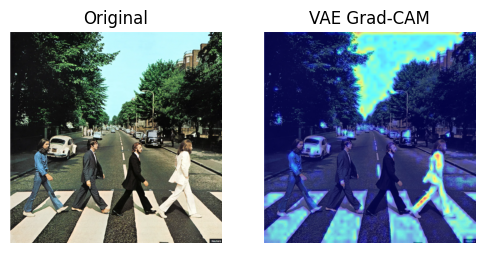

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

# -----------------------------------------
# Use VAE encoder (NOT the full pipeline)
# -----------------------------------------
target_layer = vae.encoder.down_blocks[-1].resnets[-1]
cam = GradCAM(model=vae.encoder, target_layers=[target_layer])

class DummyTarget:
    def __call__(self, model_output):
        # We just use the mean because the VAE encoder outputs a feature map,
        # not class logits.
        return model_output.mean()

def vae_gradcam(img_path):
    pil = Image.open(img_path).convert("RGB")
    rgb = np.array(pil.resize((512,512))) / 255.0

    # Same VAE preprocessing as your feature extractor
    vae_tfms = transforms.Compose([
        transforms.Resize((512,512)),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: t * 2.0 - 1.0)
    ])

    x = vae_tfms(pil).unsqueeze(0).to(device, dtype=vae.dtype)

    # Run Grad-CAM
    grayscale_cam = cam(input_tensor=x, targets=[DummyTarget()])[0]
    cam_img = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

    # Display
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(rgb); plt.axis('off'); plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(cam_img); plt.axis('off'); plt.title("VAE Grad-CAM")

    plt.show()

# Run on both image
vae_gradcam(img_ai)
vae_gradcam(img_real)